### Astrostatistic Lecture 18

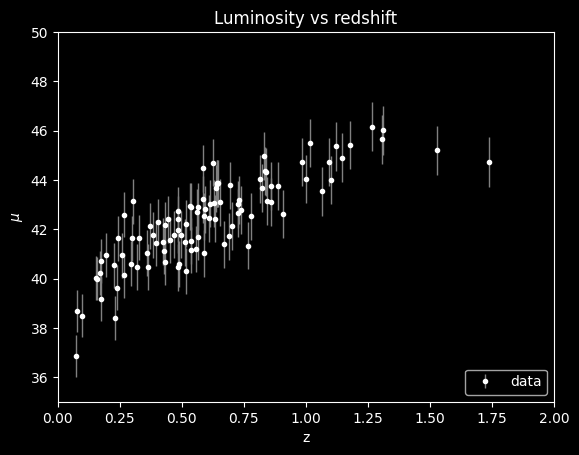

In [20]:
#capire che alpha usare su tutta sta roba se tenere 0.1 o mettere dmu (per ora uso y=mu_sample, alpha=dmu**2), in caso contrario mettere alpha=0.1**2 e y=np.random.normal(mu_sample, 0.1)
from astroML.datasets import generate_mu_z
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LinearRegression
from astroML.linear_model import PolynomialRegression
from sklearn.gaussian_process import GaussianProcessRegressor, kernels
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
import numpy as np
from tqdm import tqdm
from scipy import stats
plt.rcParams['figure.facecolor'] = 'black' #custom plot stuff
plt.rcParams['axes.facecolor'] = 'black'
plt.rcParams['axes.edgecolor'] = 'white'         
plt.rcParams['axes.labelcolor'] = 'white'  
plt.rcParams['text.color'] = 'white'  
plt.rcParams['xtick.color'] = 'white'           
plt.rcParams['ytick.color'] = 'white'

z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) ###YOU CAN'T CHANGE THIS

#just plot of the data 
plt.errorbar(z_sample, mu_sample, dmu, fmt='.', ecolor='gray', lw=1,label='data', color='white')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.title("Luminosity vs redshift")
plt.xlim(0,2)
plt.ylim(35,50)
plt.show()

best-fit theta = 0.9225090958580268


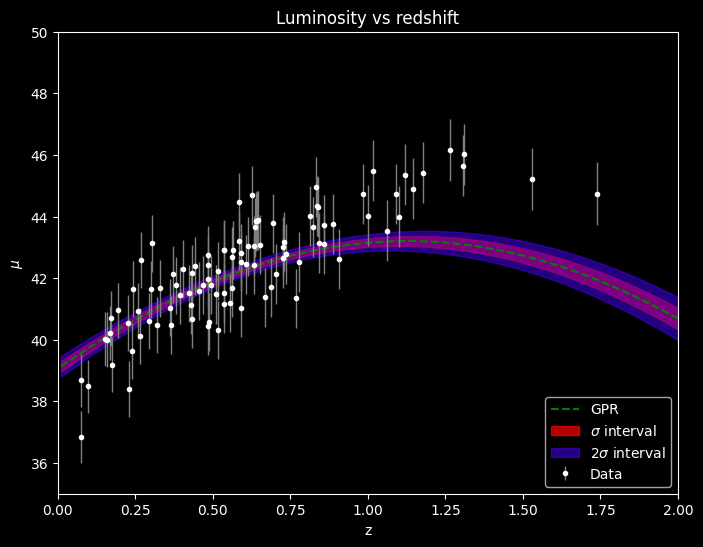

In [49]:
#try to fit the data with GPR
#we make the function pass into the data points
x = z_sample
x_test = np.linspace(0.01, 2, 10000)
y=mu_sample  #points in a distribution around the data
dy=dmu

kernel = kernels.RBF(0.1, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, alpha=dy**2, random_state=0)  #create the GPR

gp.fit(x[:, None], y)   #fit the GPR
predic, predic_err = gp.predict(x_test[:, None], 
                         return_std=True)          #predict

print("best-fit theta =", gp.kernel_.theta[0])

plt.figure(figsize=(8, 6))  #plot the GPR with confidence levels and the data 
plt.plot(x_test, predic, linestyle='dashed', color='green', label='GPR')
plt.fill_between(x_test, predic - predic_err, predic + predic_err, 
                color="#FF0000FF", alpha=0.7, label=r'$\sigma$ interval')
plt.fill_between(x_test, predic - 2 * predic_err, predic + 2 * predic_err, 
                color="#4800FF", alpha=0.5, label=r'2$\sigma$ interval')
plt.errorbar(z_sample, mu_sample , dmu, fmt='.', ms=6, ecolor='gray', lw=1, label='Data', color='white')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.title("Luminosity vs redshift")
plt.xlim(0,2)
plt.ylim(35,50)
plt.show()

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:01<00:00, 78.39it/s]


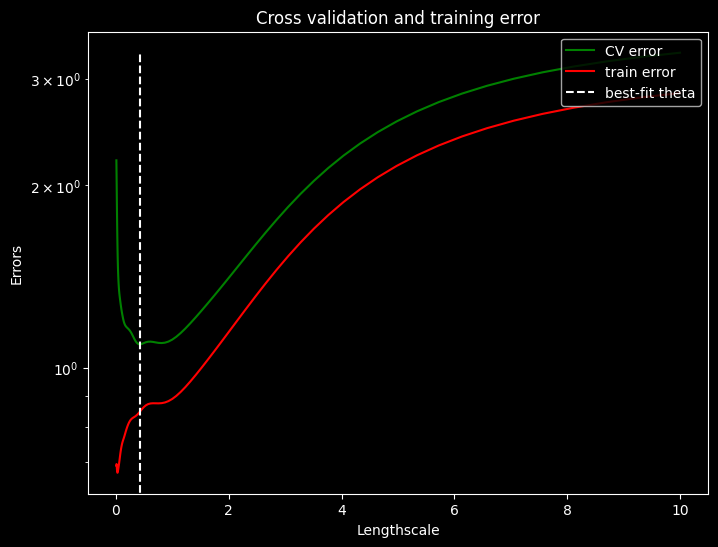

best-fit theta = 0.43287612810830595


In [50]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
# now we need to do a cross validation on the GPR lengthscale

kf = KFold(n_splits=5, shuffle=True, random_state=42)   #use a 5-fold cross validation for the GPR lengthscale
scores=[]
t_scores=[]
lengthscale = np.logspace(-2, 1, 100)

for l in tqdm(lengthscale):     #cycle over the lengthscale
    fold_errors = []
    t_err = []
    for train_idx, test_idx in kf.split(x):     #for each l we do a 5-fold cross validation
        X_train, X_test = x[train_idx], x[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        dmu_train=dmu[train_idx]
        kernel=kernels.RBF(l, length_scale_bounds='fixed')
        gp = GaussianProcessRegressor(kernel=kernel, alpha=dmu_train**2, random_state=0, normalize_y=True)
        gp.fit(X_train[:, None], y_train)
        y_pred = gp.predict(X_test[:, None])
        error = error = np.mean(((y_test - y_pred) / dmu[test_idx])**2)
        fold_errors.append(error)
        train_error = mean_squared_error(y_train, gp.predict(X_train[:, None]))
        t_err.append(train_error)
    scores.append(np.mean(fold_errors))     #append the mean of the errors for test and train sets
    t_scores.append(np.mean(t_err))
best_l = lengthscale[np.argmin(scores)]

plt.figure(figsize=(8, 6))      #plot the cross validation errors and training errors
plt.plot(lengthscale, scores, color='green', label='CV error')
plt.plot(lengthscale, t_scores, color='red', label='train error')
plt.vlines(best_l, 0, np.max(scores), color='white', ls='dashed', lw=1.5, label='best-fit theta')
plt.xlabel("Lengthscale")
plt.ylabel("Errors")
plt.title("Cross validation and training error")
plt.legend(loc='upper right')
plt.yscale('log')
plt.show()

print("best-fit theta =", best_l)     #best-fit lengthscale

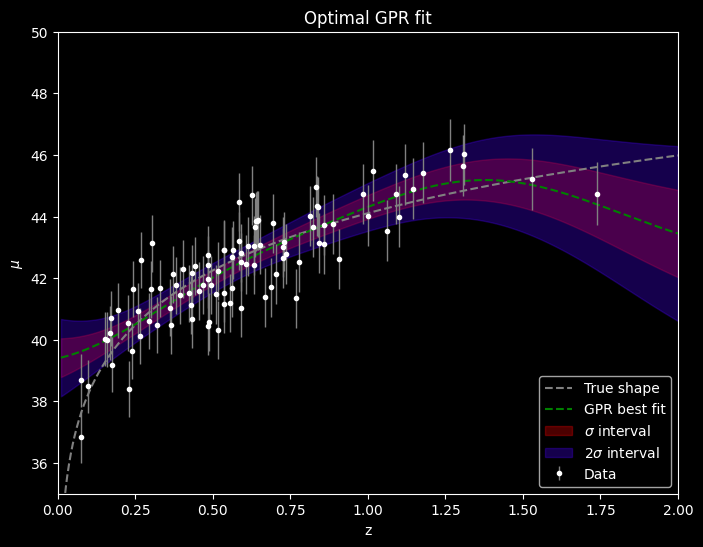

In [45]:
from astropy.cosmology import LambdaCDM

#true model
cosmo = LambdaCDM(H0=71, Om0=0.27, Ode0=1-0.27)
z = np.linspace(0.01, 2, 1000)
mu_true = cosmo.distmod(z)

#best parametern fit and comparison
x = z_sample
x_test = np.linspace(0.01, 2, 1000)
y=mu_sample

kernel = kernels.RBF(length_scale=best_l, length_scale_bounds="fixed")

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=dmu**2,
    normalize_y=True,
    random_state=0
)

gp.fit(x[:, None], y)

predic, predic_err = gp.predict(
    x_test[:, None],
    return_std=True
)

plt.figure(figsize=(8, 6))
plt.plot(z, mu_true, '--', c='gray', label='True shape')
plt.plot(x_test, predic, linestyle='dashed', color='green', label='GPR best fit')
plt.fill_between(x_test, predic - predic_err, predic + predic_err, 
                color="#FF0000FF", alpha=0.3, label=r'$\sigma$ interval')
plt.fill_between(x_test, predic - 2 * predic_err, predic + 2 * predic_err, 
                color="#4800FF", alpha=0.3, label=r'2$\sigma$ interval')
plt.errorbar(z_sample, mu_sample , dmu, fmt='.', ms=6, ecolor='gray', lw=1, label='Data', color='white', zorder=3)
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.title("Optimal GPR fit")
plt.xlim(0,2)
plt.ylim(35,50)
plt.show()

4191


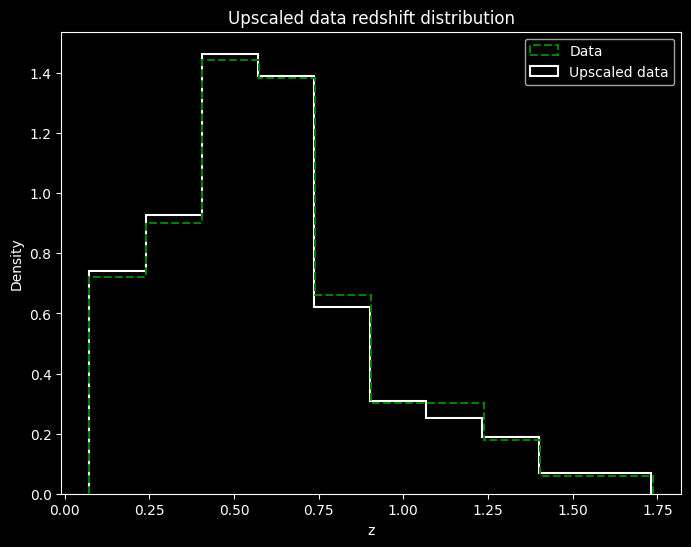

In [46]:
#now from this fit we can get the pdf of the data and clone them to generate a bigger sample with same characteristics

#first we need to have the same z distribution so we do a rejection sampling in z and plot the distributions to check 
hist, bins = np.histogram(z_sample, bins=10, density=True)

x = np.random.uniform(min(z_sample), max(z_sample), 10000)
y = np.random.uniform(0, hist.max(), 10000)

idx = np.digitize(x, bins) - 1
idx = np.clip(idx, 0, len(hist)-1)

picked_z = x[y < hist[idx]]

print(len(picked_z))
plt.figure(figsize=(8, 6))
plt.hist(z_sample, bins=10, density=True, histtype="step", label='Data', color='green', linestyle='dashed', zorder=3, lw=1.5)
plt.hist(picked_z, bins=10, density=True, histtype="step", label='Upscaled data', color='white', lw=1.5)
plt.legend(loc='upper right')
plt.xlabel("z")
plt.ylabel("Density")
plt.title("Upscaled data redshift distribution")
plt.show()


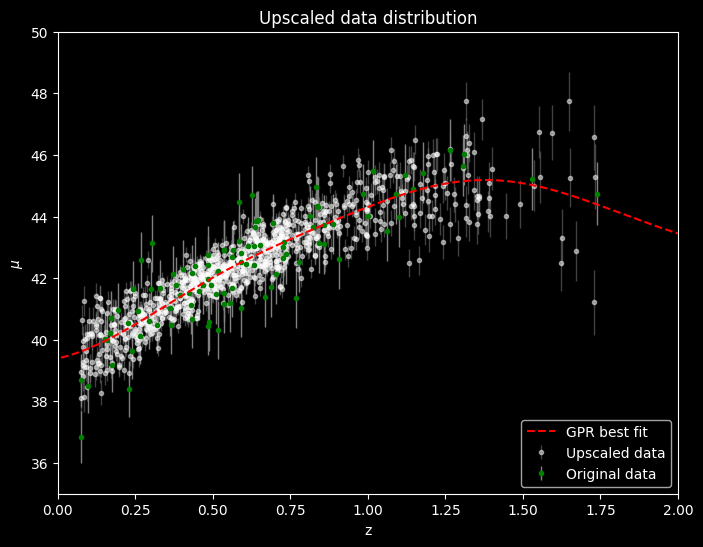

In [47]:
#we want to upscale by 10 the z_sample 
length = len(z_sample)*10
z_fake = np.random.choice(picked_z, size=length)    #from the picked z we sample 1000 values

predic_mu, predic_err_mu = gp.predict(          #now we predict the mu and the error for each new point
    z_fake[:, None],
    return_std=True
)

samples = np.random.normal(loc=predic_mu, scale=2*predic_err_mu)      #for every prediction we consider a gaussian distribution
mu_up = samples.T.flatten()     

plt.figure(figsize=(8, 6))
plt.errorbar(z_fake, mu_up , predic_err_mu, fmt='.', ms=6, ecolor='gray', lw=1, label='Upscaled data', color='white', alpha=0.5)
plt.errorbar(z_sample, mu_sample , dmu, fmt='.', ms=6, ecolor='gray', lw=1, label='Original data', color='green')
plt.plot(x_test, predic, linestyle='dashed', color='red', label='GPR best fit', zorder=3)
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.title("Upscaled data distribution")
plt.xlim(0,2)
plt.ylim(35,50)
plt.show()

